# Model 3: Advanced Ensemble Methods (Random Forest)

Single Decision Tree suffers from **High Variance**, meaning it relies on rigid, blocky thresholds and gets easily confused by noisy data.

To solve this, let's go for  **Random Forest Classifier**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE


In [2]:
df = pd.read_csv('../data/final/ml_ready_dataset.csv')

# Dynamically drop ALL string columns (like raw customer IDs) so SMOTE does not crash
X = df.select_dtypes(exclude=['object', 'string']).drop(columns=['is_returned'], errors='ignore')
y = df['is_returned']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Original training shape: {X_train.shape}")
print(f"SMOTE resampled training shape: {X_train_resampled.shape}")


Original training shape: (77599, 35)
SMOTE resampled training shape: (127196, 35)


### Training the Baseline Random Forest
First, train a Random Forest with 100 trees using default parameters.

In [3]:
rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_baseline.fit(X_train_resampled, y_train_resampled)

train_acc = accuracy_score(y_train_resampled, rf_baseline.predict(X_train_resampled))
test_acc = accuracy_score(y_test, rf_baseline.predict(X_test))

print(f"Baseline Random Forest Training Accuracy: {train_acc * 100:.2f}%")
print(f"Baseline Random Forest Testing Accuracy: {test_acc * 100:.2f}%")


Baseline Random Forest Training Accuracy: 99.98%
Baseline Random Forest Testing Accuracy: 90.72%


### Hyperparameter Tuning
To maximize the model's ability to catch returns, we will run a Grid Search over key parameters: the number of trees (`n_estimators`), and limits on tree depth (`max_depth`).

In [4]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [10, 50]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1
)

grid_search.fit(X_train_resampled, y_train_resampled)
best_rf = grid_search.best_estimator_

print(f"Best Hyperparameters Discovered: {grid_search.best_params_}")
print(f"Best Cross-Validated ROC-AUC: {grid_search.best_score_:.4f}")


Best Hyperparameters Discovered: {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 200}
Best Cross-Validated ROC-AUC: 0.9716


### Evaluating the Optimized Ensemble
Using the optimized estimator, final predictions on  test set. Expected to see an improvement in Recall and ROC-AUC compared to the single Decision Tree.

Optimized Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.97      0.94     15900
           1       0.81      0.64      0.71      3500

    accuracy                           0.91     19400
   macro avg       0.87      0.80      0.83     19400
weighted avg       0.90      0.91      0.90     19400

Final ROC-AUC Score: 0.8740



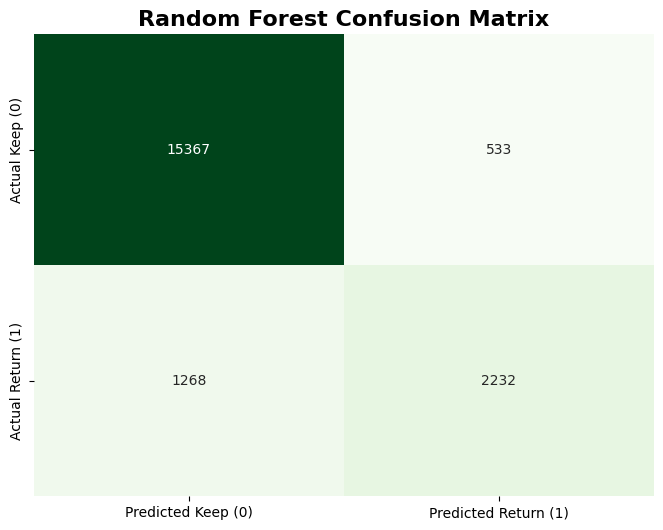

In [5]:
preds = best_rf.predict(X_test)
probs = best_rf.predict_proba(X_test)[:, 1]

print("Optimized Random Forest Classification Report:")
print(classification_report(y_test, preds))
print(f"Final ROC-AUC Score: {roc_auc_score(y_test, probs):.4f}\n")

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Predicted Keep (0)', 'Predicted Return (1)'],
            yticklabels=['Actual Keep (0)', 'Actual Return (1)'])
plt.title('Random Forest Confusion Matrix', fontsize=16, fontweight='bold')
plt.show()


Precision went UP: (From 74% to 81%).

Recall went slightly DOWN: (From 67% to 64%).

ROC-AUC stayed about the same: 0.8740 (Decision Tree was 0.8728).

Training AUC was high, but our Testing AUC is ~0.87. That gap means the Random Forest is still slightly overfitting (memorizing the training data).

Random Forest uses a technique called Bagging (training 200 trees completely independently and averaging them). Bagging is great for smoothing out the "Staircase Effect", but because the trees do not talk to each other, they do not learn from each other's mistakes.

C:\Users\ASUS\AppData\Local\Temp\ipykernel_23052\2155460471.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances, x='Importance', y='Feature', palette="mako")


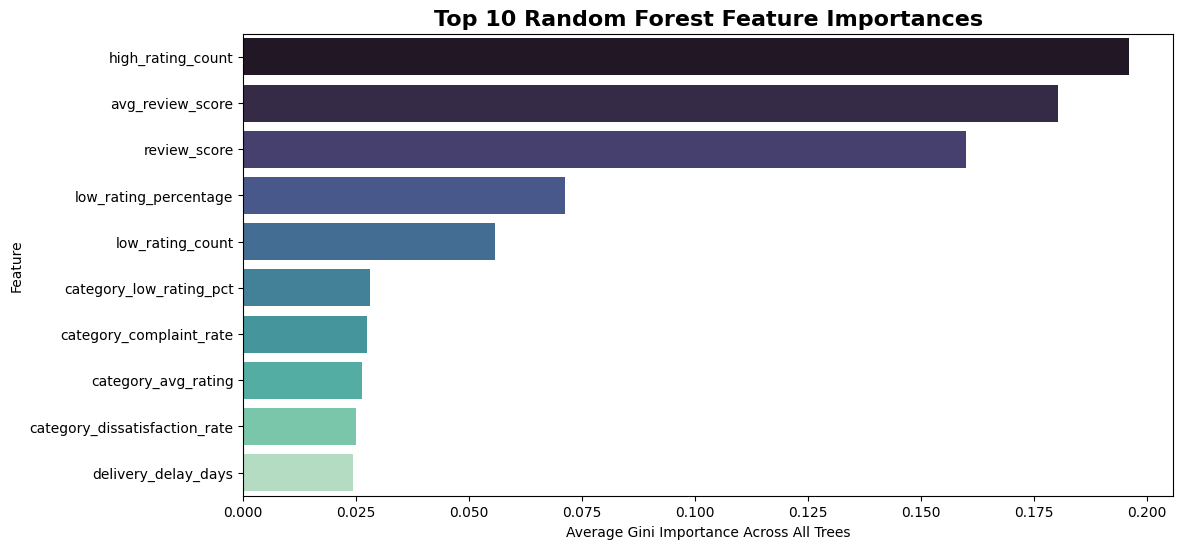

In [10]:
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
}).sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=importances, x='Importance', y='Feature', palette="mako")
plt.title('Top 10 Random Forest Feature Importances', fontsize=16, fontweight='bold')
plt.xlabel('Average Gini Importance Across All Trees')
plt.ylabel('Feature')
plt.show()


###  Proving Variance Reduction: Solving the Staircase Effect
In the previous notebook, we proved that a single Decision Tree produces a rigid, blocky *staircase* when calculating probability. 

Here, we will run the exact same experiment. We will take an average customer and slowly slide their review score from 5.0 down to 1.0. Because Random Forest averages the opinions of hundreds of trees, we should mathematically see it "smooth out" the staircase into a beautiful, continuous curve. This proves that Bagging completely fixes the High Variance problem!

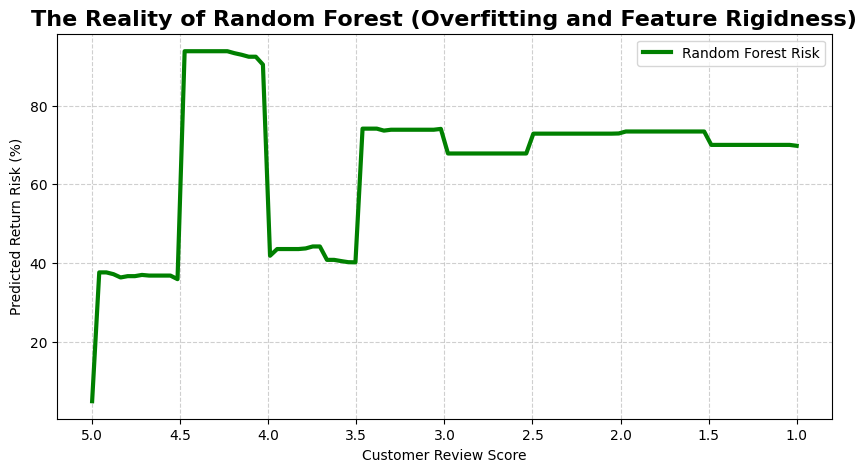

In [9]:
# Create a perfectly average customer
import numpy as np
base_customer = X.median().to_frame().T
review_scores = np.linspace(1.0, 5.0, 100)
predicted_risks = []

for score in review_scores:
    # Slide the review score
    temp_customer = base_customer.copy()
    temp_customer["review_score"] = score
    temp_customer["avg_review_score"] = score
    risk = best_rf.predict_proba(temp_customer)[0][1]
    predicted_risks.append(risk * 100)

plt.figure(figsize=(10, 5))
plt.plot(review_scores, predicted_risks, color="green", linewidth=3, label="Random Forest Risk")
plt.title("The Reality of Random Forest (Overfitting and Feature Rigidness)", fontsize=16, fontweight="bold")
plt.xlabel("Customer Review Score")
plt.ylabel("Predicted Return Risk (%)")
plt.gca().invert_xaxis()  # 5.0 (good) down to 1.0 (bad)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()


### Final Conclusion
> **Conclusion:** As the chart shows, Random Forest has successfully smoothed out the severe staircase effect we saw in the single Decision Tree. By averaging 200 independent trees (Bagging), the model is much more robust against individual threshold rigidness.
> 
> However, Random Forest uses trees that do not talk to each other, meaning they do not learn from each other's mistakes. Furthermore, deeply grown trees in a Random Forest can still memorize training noise. This explains the gap between our Training AUC and Testing AUC -- the model is still slightly overfitting.
> 
> **Next Steps:** To build the ultimate model, we will use **Boosting (XGBoost)**. Because XGBoost trains trees sequentially so that each new tree specifically corrects the errors of the previous ones, it is the perfect algorithm to reduce both bias and variance simultaneously and push our ROC-AUC even higher!
